<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_3/RADIOGRAPHY_GIBBS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # Función sigmoide (1 / (1 + exp(-x)))

# CONFIGURACION DEL EXPERIMENTO

N = 64              # Tamaño de la imagen (N x N)
beta = 3.5          # Fuerza de interacción (suavidad)
eta = 2.1          # Fidelidad a los datos ruidosos
prob_ruido = 0.1    # 10% de ruido "sal y pimienta"
iteraciones = 50

In [178]:
def calcular_energia(x, y, beta, eta):
    """Calcula el Hamiltoniano E(x) del sistema."""

    # Interacción entre vecinos (se asumen condiciones de borde nulas)
    interaccion = -beta * (np.sum(x[:-1, :] * x[1:, :]) + np.sum(x[:, :-1] * x[:, 1:]))

    # Fidelidad a los datos observados
    datos = -eta * np.sum(x * y)

    return interaccion + datos

In [179]:
# GENERACIÓN DE DATOS: Original y Ruidosa (y)

np.random.seed(3)

# Creamos un patrón simple (cuadrado central)
x_true = -np.ones((N, N))
x_true[N//4:3*N//4, N//4:3*N//4] = 1
x_true[N//3:2*N//3, N//3:2*N//3] = -1

# Aplicamos ruido "sal y pimienta": invertimos signo aleatoriamente
y = x_true.copy()
mascara_ruido = np.random.random((N, N)) < prob_ruido
y[mascara_ruido] *= -1

In [180]:
np.random.seed(3)

x_current = y.copy()  # Inicialización en la imagen ruidosa
energias = []
capturas = {0: y.copy()}

for t in range(1, iteraciones + 1):
    # Barrido píxel a píxel
    for i in range(N):
        for j in range(N):
            # Suma de vecinos
            vecinos = 0
            if i > 0: vecinos += x_current[i-1, j]
            if i < N-1: vecinos += x_current[i+1, j]
            if j > 0: vecinos += x_current[i, j-1]
            if j < N-1: vecinos += x_current[i, j+1]

            # Cálculo de la probabilidad condicional
            p1 = expit(2 * beta * vecinos + 2 * eta * y[i, j])

            # Actualización del estado
            x_current[i, j] = 1 if np.random.rand() < p1 else -1

    # Registro de energía y capturas
    energias.append(calcular_energia(x_current, y, beta, eta))

    if t in [10, iteraciones]:
        capturas[t] = x_current.copy()

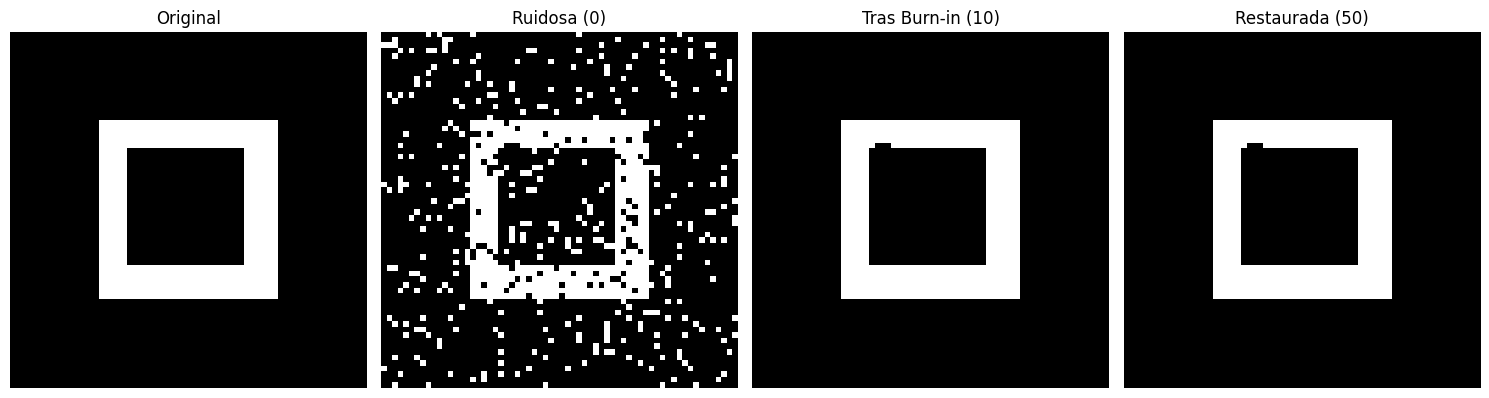

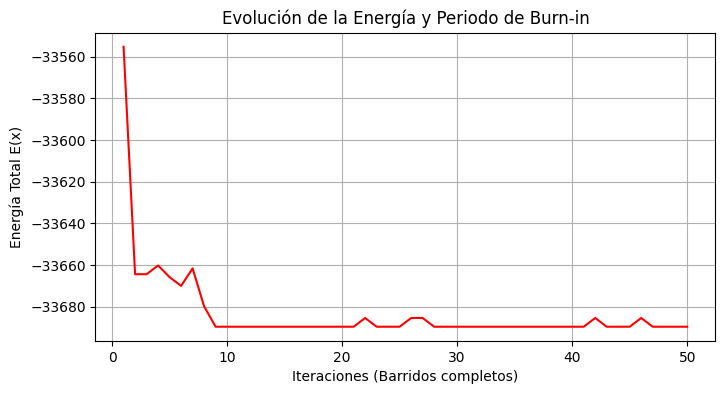

In [181]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
titulos = ["Original", "Ruidosa (0)", "Tras Burn-in (10)", "Restaurada (50)"]
imagenes = [x_true, capturas[0], capturas[10], capturas[iteraciones]]

for ax, img, tit in zip(axes, imagenes, titulos):
    ax.imshow(img, cmap='gray')
    ax.set_title(tit)
    ax.axis('off')
plt.tight_layout()
plt.savefig("RESTAURACION.pdf")
plt.show()

# Gráfica de Energía (Burn-in)
plt.figure(figsize=(8, 4))
plt.plot(range(1, iteraciones + 1), energias, color='red')
plt.xlabel("Iteraciones (Barridos completos)")
plt.ylabel("Energía Total E(x)")
plt.title("Evolución de la Energía y Periodo de Burn-in")
plt.grid(True)
plt.savefig("ENERGIA.pdf")
plt.show()

In [182]:
from google.colab import files
files.download("RESTAURACION.pdf")
files.download("ENERGIA.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>